In [12]:
import mina
import scanpy as sc
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt

There are circumstances where you have two different studies and one would like to explore shared and unique variability associated with them. Here we have two batches of a single study of IBD to show that this is possible, using MOFA grouping strategy

In [58]:
# Doing pre-processing of dataset number 1
adata = sc.read_h5ad("./data/scIBD/KongEpi_adata_ref.h5ad")
adata = adata[adata.obs["organ"] == "Ileum", :].copy()
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
metadata["study_group"] = "KongChemA"
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)

# Processing
mina.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=20)
mina.up.filt.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filt.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filt.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filt.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
#mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)

/Users/flores/Dropbox/EBI/Research/MINA/src/mina/up/pp.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/flores/Dropbox/EBI/Research/MINA/src/mina/up/pp.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['H101694_E', 'H101694_L', 'H102141_E', 'H102141_L', 'H110216_E']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/Users/flores/Dropbox/EBI/Research/MINA/src/mina/up/filt.py:126: RuntimeWarning: invalid value encountered in divide
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide


In [59]:
# Doing pre-processing of dataset number 2
adata_proj = sc.read_h5ad("./data/scIBD/KongEpi_adata_proj.h5ad")
# Process adata_raw
metadata_proj = mina.up.extract_metadata_from_obs(obs=adata_proj.obs, groupby="biosample_id", sort=False)
metadata_proj["study_group"] = "KongChemB"
pdata_proj = dc.pp.pseudobulk(adata_proj, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata_proj.obs = pdata_proj.obs.set_index("biosample_id", drop=False)
pdata_proj.obs.index.name = None
anndata_dict_proj = mina.up.split_anndata_by_celltype(pdata=pdata_proj, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict_proj.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

mina.up.filter_anndata_by_ncells(anndata_dict_proj, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata_proj.index)
min_samples = math.trunc(n_samples * 0.4)
mina.up.filter_views_by_samples(anndata_dict_proj, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict_proj, min_count=5, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict_proj, min_genes_per_view=20)
mina.up.filter_samples_by_coverage(anndata_dict_proj, threshold=0, min_prop=0.90)
mina.up.filter_views_by_samples(anndata_dict_proj, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict_proj, layer_name="raw_counts")
mina.up.norm_log(anndata_dict_proj, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
#mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
#mina.up.append_view_to_var(anndata_dict_proj)

/Users/flores/Dropbox/EBI/Research/MINA/src/mina/up/pp.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/flores/Dropbox/EBI/Research/MINA/src/mina/up/pp.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['H106265_N', 'H139073_N', 'H158108_N1', 'H158108_N2', 'H158108_N3']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


In [60]:
# Merging datasets
anndata_merged = mina.up.merge_adata_views(
    studies = [anndata_dict, anndata_dict_proj],
    study_names = ["ChemA", "ChemB"],
    view_mode = "intersection",
    min_view_studies = 2,
    var_mode = "inner",
    min_var_studies = 2
)

mina.up.utils.append_view_to_var(anndata_merged)

In [61]:
metadata_merged = pd.concat([metadata, metadata_proj], join="inner", axis=0)

In [62]:
metadata_merged

,biosample_id,donor_id,organ,library_preparation_protocol,study,disease,tissue_sample_status,celltype_compartment,biosample_enriched_fraction,study_group
H101694_E,H101694_E,101694,Ileum,10x 3' v3,Kong et al.,Non-IBD,Non-IBD,epithelial,Epi,KongChemA
H101694_L,H101694_L,101694,Ileum,10x 3' v3,Kong et al.,Non-IBD,Non-IBD,epithelial,LP,KongChemA
H102141_E,H102141_E,102141,Ileum,10x 3' v3,Kong et al.,Non-IBD,Non-IBD,epithelial,Epi,KongChemA
H102141_L,H102141_L,102141,Ileum,10x 3' v3,Kong et al.,Non-IBD,Non-IBD,epithelial,LP,KongChemA
H110216_E,H110216_E,110216,Ileum,10x 3' v3,Kong et al.,Non-IBD,Non-IBD,epithelial,Epi,KongChemA
...,...,...,...,...,...,...,...,...,...,...
N166301_N1,N166301_N1,166301,SmallBowel,10x 3' v2,Kong et al.,CD,Non-inflamed,epithelial,Whole,KongChemB
N166301_N2,N166301_N2,166301,SmallBowel,10x 3' v2,Kong et al.,CD,Non-inflamed,epithelial,Whole,KongChemB
N166301_N3,N166301_N3,166301,SmallBowel,10x 3' v2,Kong et al.,CD,Non-inflamed,epithelial,Whole,KongChemB
N175041_N1,N175041_N1,175041,Colon,10x 3' v2,Kong et al.,CD,Non-inflamed,epithelial,Whole,KongChemB


In [64]:
model_data = md.MuData(anndata_merged)
model_data.obs["study_group"] = model_data.obs.index.map(metadata_merged["study_group"])

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


2026-03-20 13:18:59 | [WARNING] Device cuda is not available. Using default device: cpu


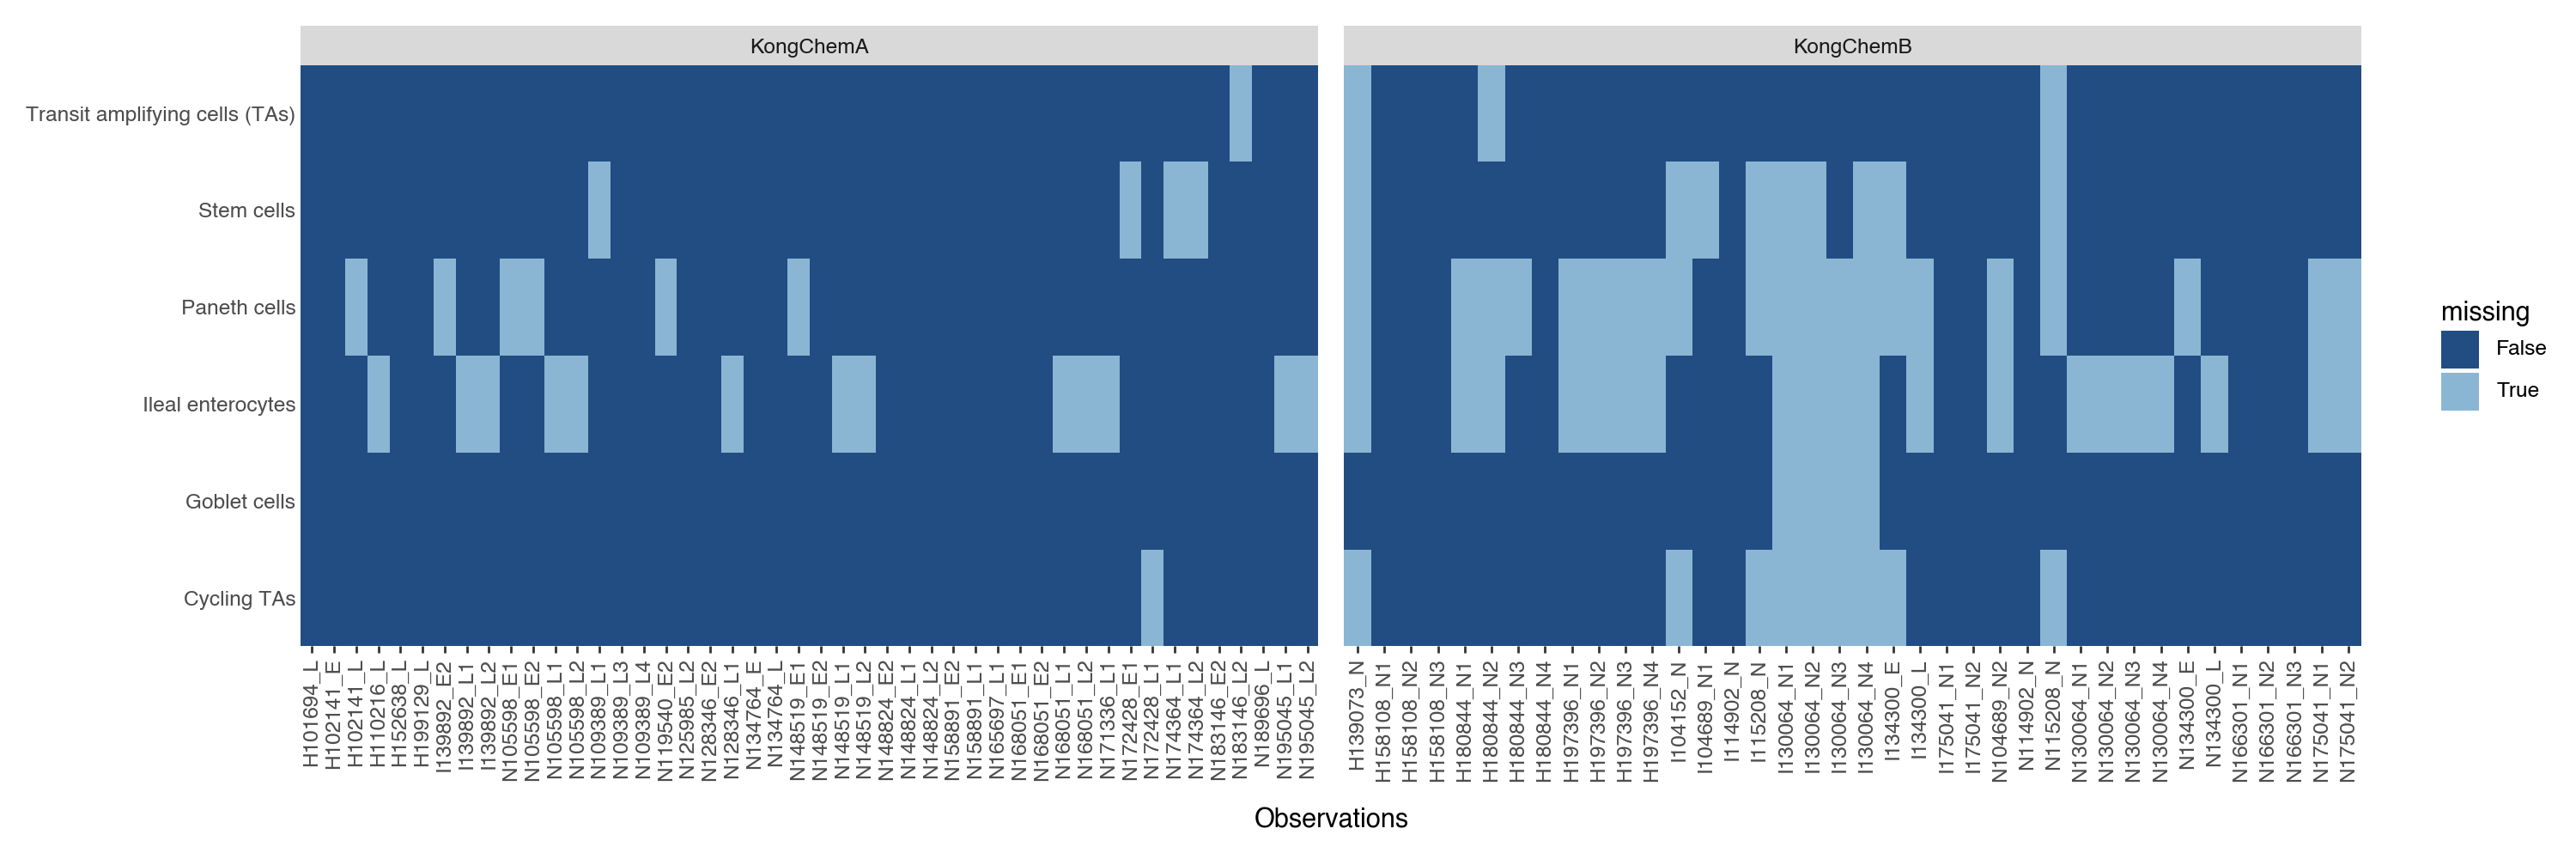

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
2026-03-20 13:18:59 | [INFO] Initializing factors using `random` method...
 24%|██▍       | 2386/10000 [03:11<10:10, 12.47epochs/s, Loss=3.09e+4]


In [65]:
model_group = mf.MOFAFLEX(
    model_data,
    mf.ModelOptions(n_factors=8, weight_prior="SnS", likelihoods="Normal"),
    mf.DataOptions(group_by="study_group"),
    mf.TrainingOptions(seed=42, save_path=False, lr=0.01, early_stopper_patience=500)
)

The difference in this model is that you are modeling the variability of cell-types and groups simultaneously, thus finding unique things for chemistry A or chemistry B

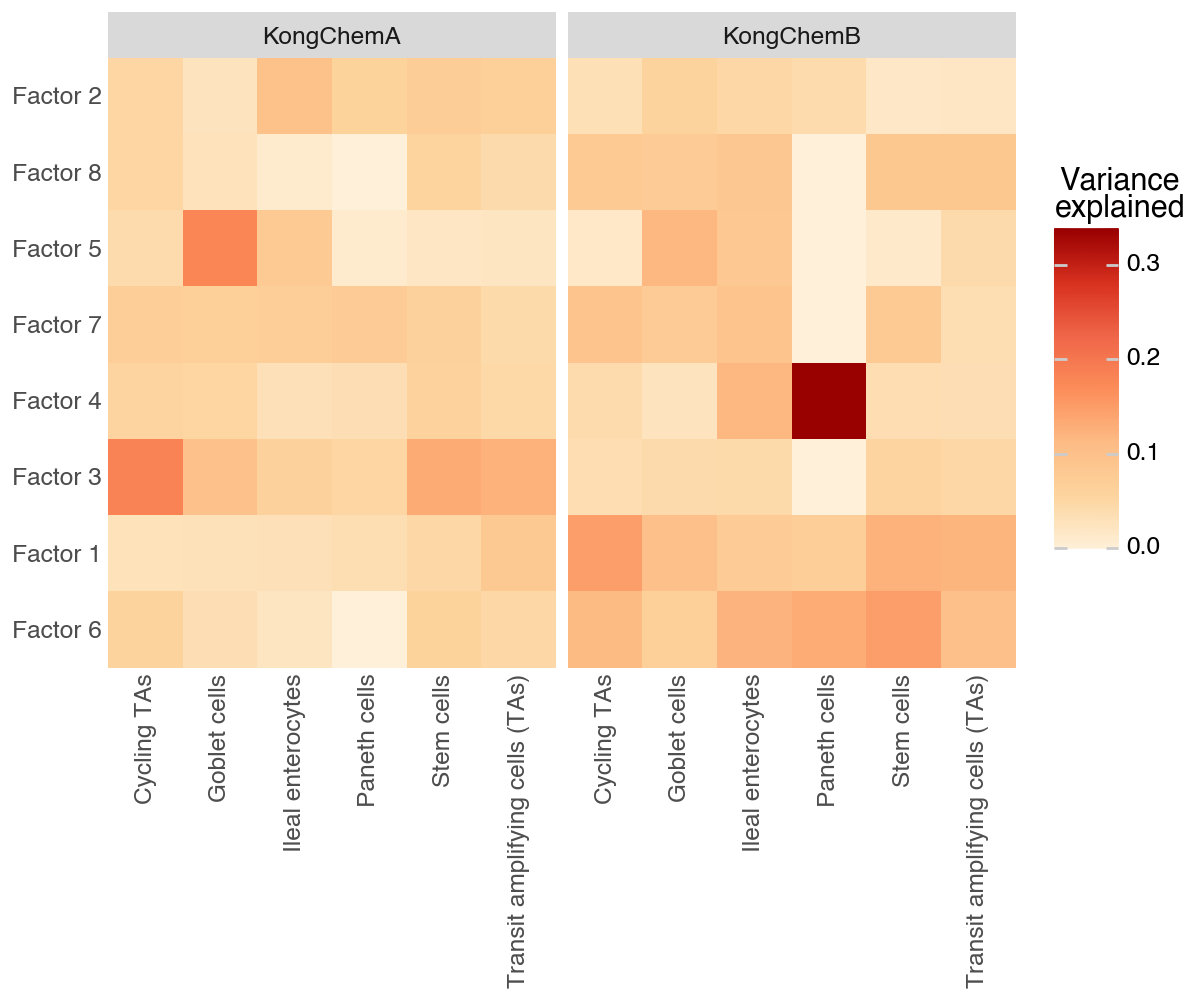

In [66]:
mf.pl.variance_explained(model_group)

Similarly as before, you can save your model in an anndata to continue with the downstream analyses

In [68]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_merged,
    metadata=metadata_merged,
    model=model_group,
)

## Doing statistics with the models

Given the availability of multiple groups one can do associations controling for random effects

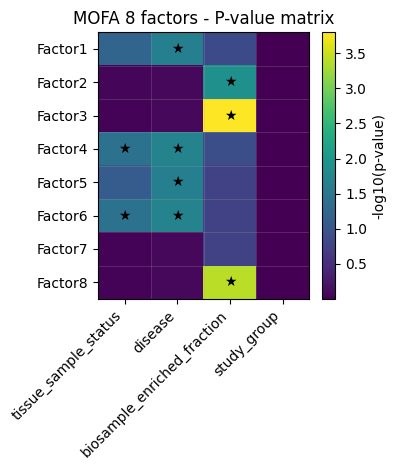

In [72]:
all_assocs = mina.down.get_pval_matrix(amodel,["tissue_sample_status", "disease", "biosample_enriched_fraction", "study_group"])

mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 8 factors - P-value matrix")
plt.show()

In [71]:
mina.down.get_associations(amodel, 
                           test_variable = "disease",
                           test_type="categorical", 
                           random_effect = "study_group")

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed t

,feature,statistic,p_value,adj_p_value
0,Factor1,2.618180,0.008840,0.017680
1,Factor2,-0.362015,0.717341,0.809141
2,Factor3,0.241534,0.809141,0.809141
3,Factor4,-3.068852,0.002149,0.011040
4,Factor5,2.639245,0.008309,0.017680
5,Factor6,-2.993285,0.002760,0.011040
6,Factor7,0.467775,0.639946,0.809141
7,Factor8,0.624294,0.532434,0.809141


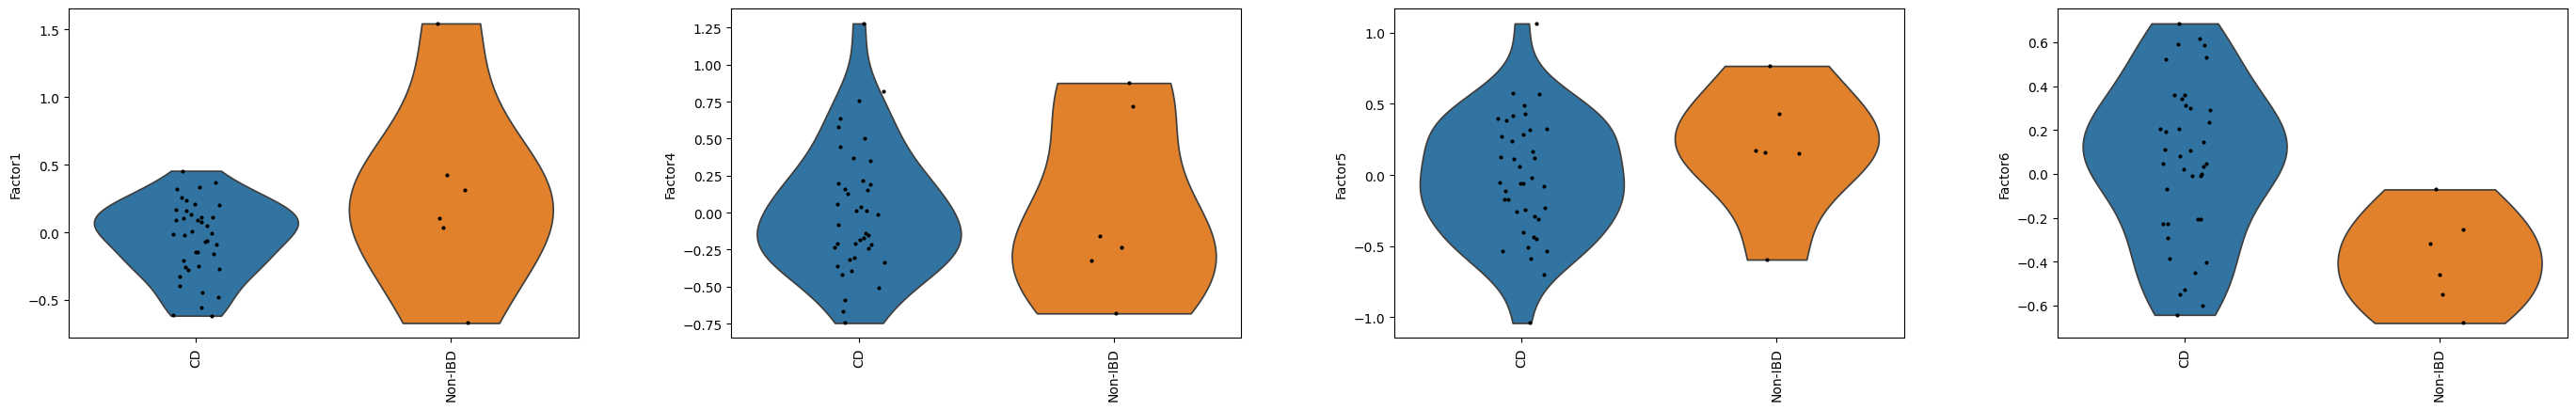

In [80]:
sc.pl.violin(amodel[amodel.obs["study_group"] == "KongChemA"],
             ["Factor1", "Factor4", "Factor5", "Factor6"], 
             groupby="disease", rotation=90,size = 3)

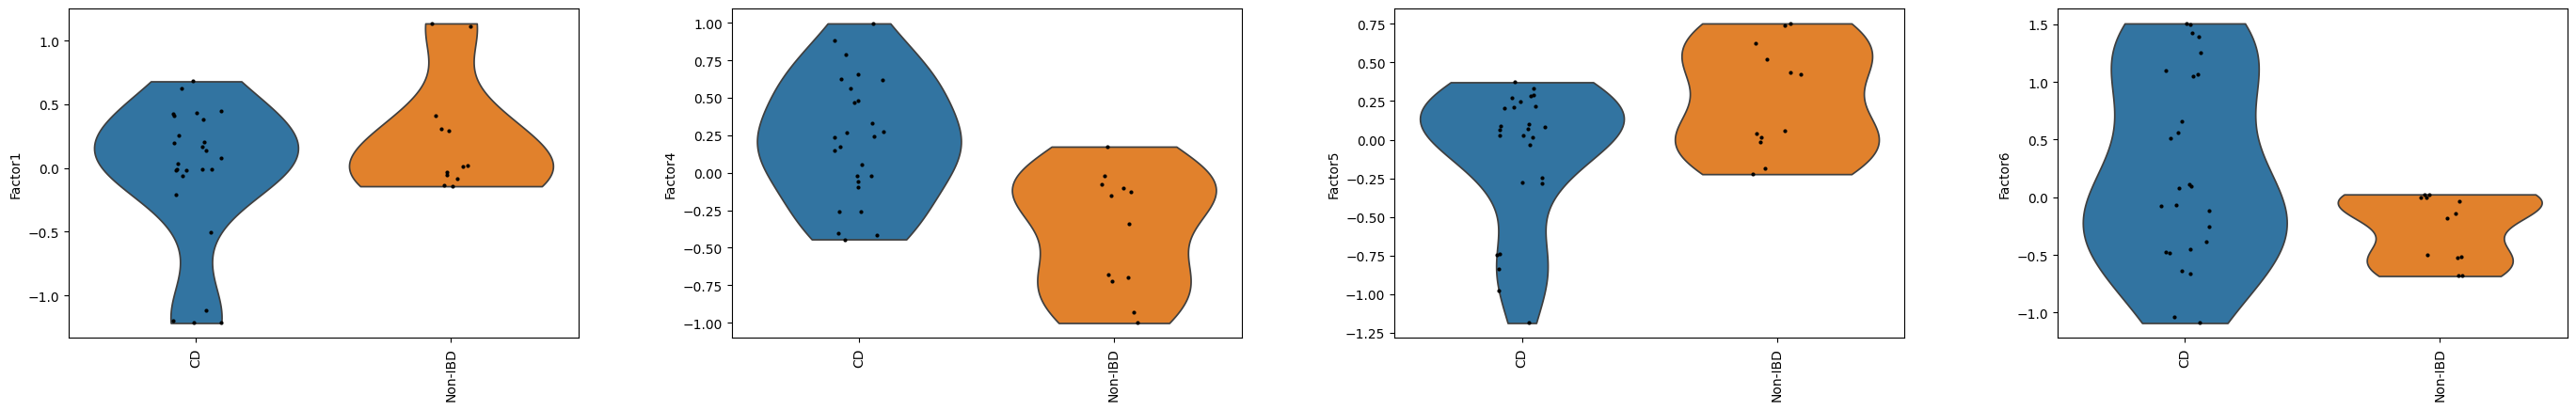

In [81]:
sc.pl.violin(amodel[amodel.obs["study_group"] == "KongChemB"],
             ["Factor1", "Factor4", "Factor5", "Factor6"], 
             groupby="disease", rotation=90,size = 3)

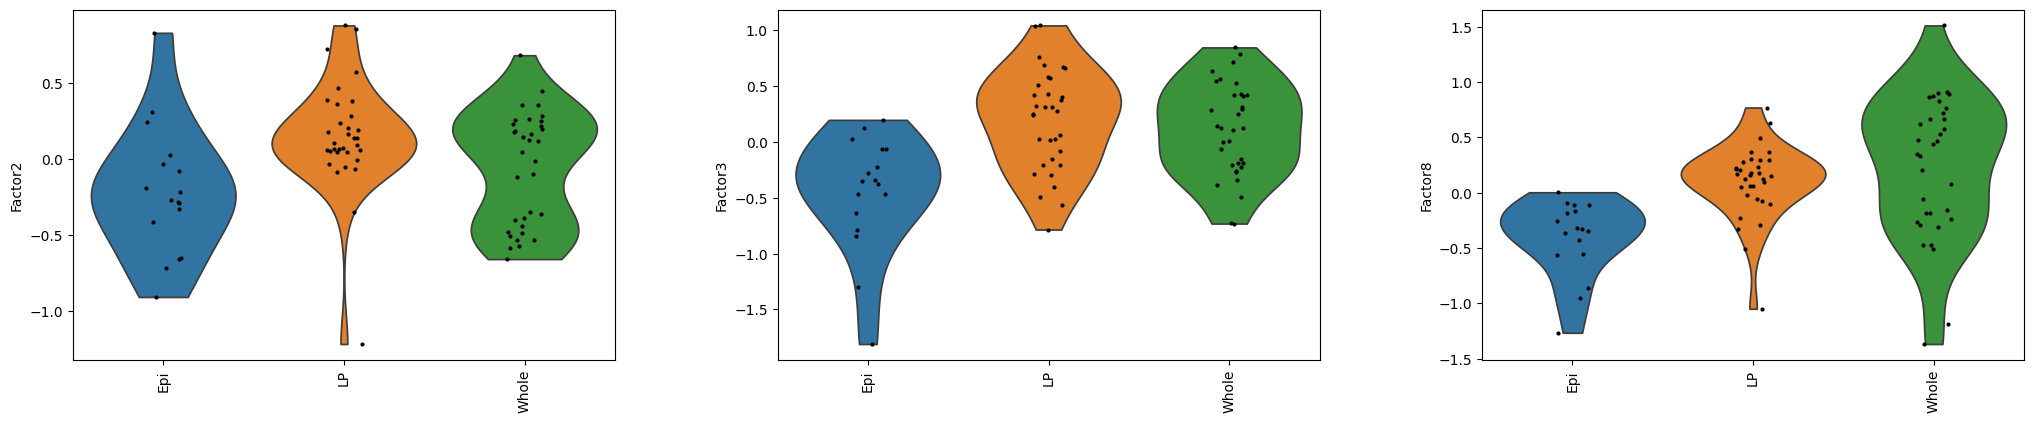

In [74]:
sc.pl.violin(amodel, 
             ["Factor2", "Factor3", "Factor8"], 
             groupby="biosample_enriched_fraction", rotation=90,size = 3)

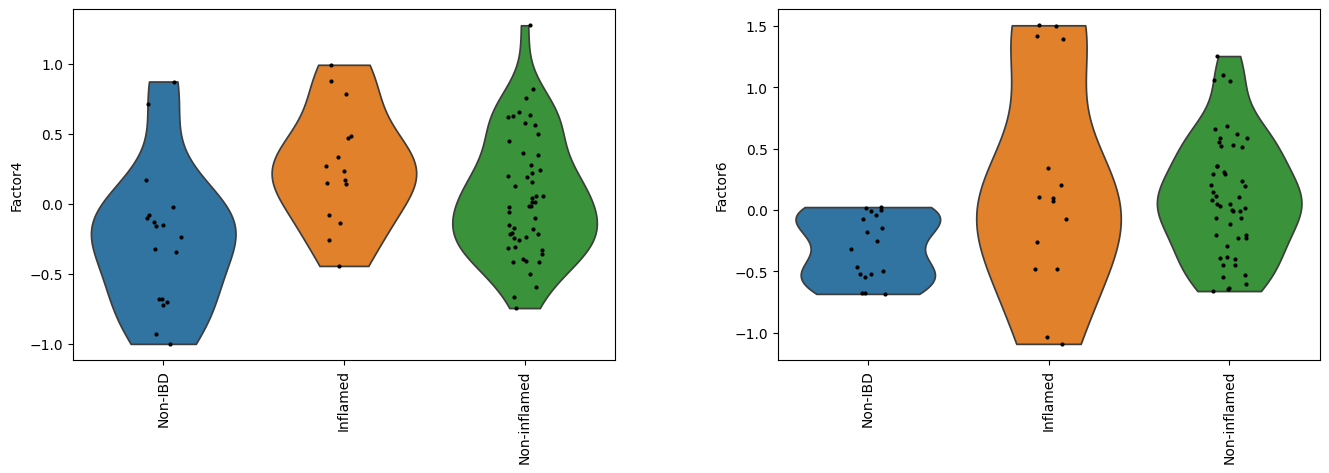

In [75]:
sc.pl.violin(amodel, 
             ["Factor4", "Factor6"], 
             groupby="tissue_sample_status", rotation=90,size = 3)

In [ ]:
amodel[amodel.obs["study_group"] == "ChemA"]

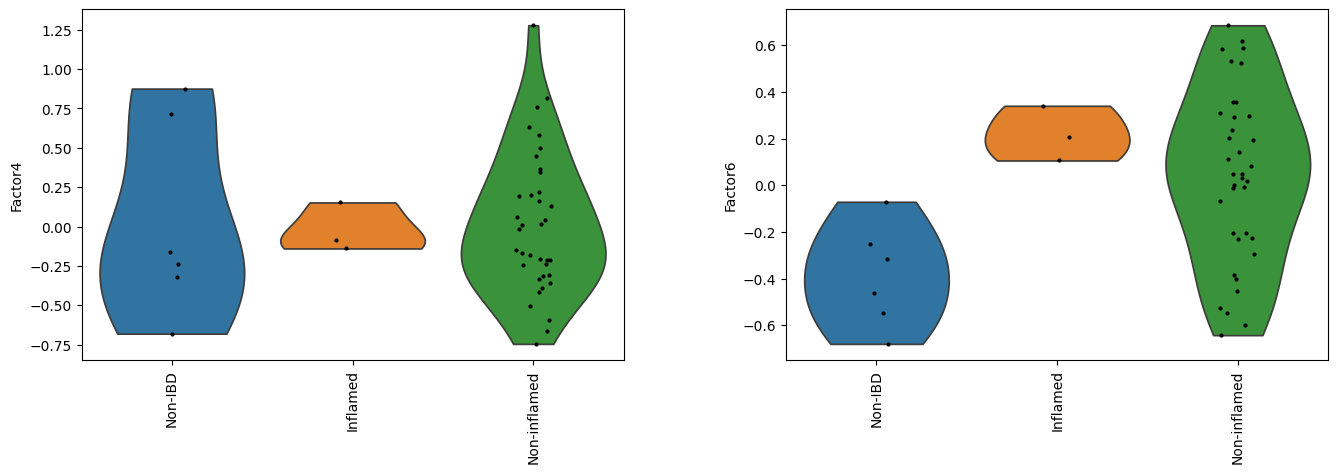

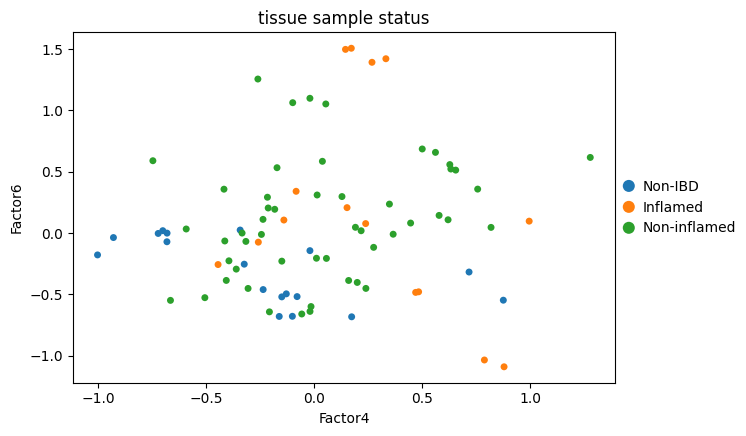

In [76]:
sc.pl.scatter(amodel,
              x = "Factor4",
              y = "Factor6", 
              color  = "tissue_sample_status", 
              size =100)

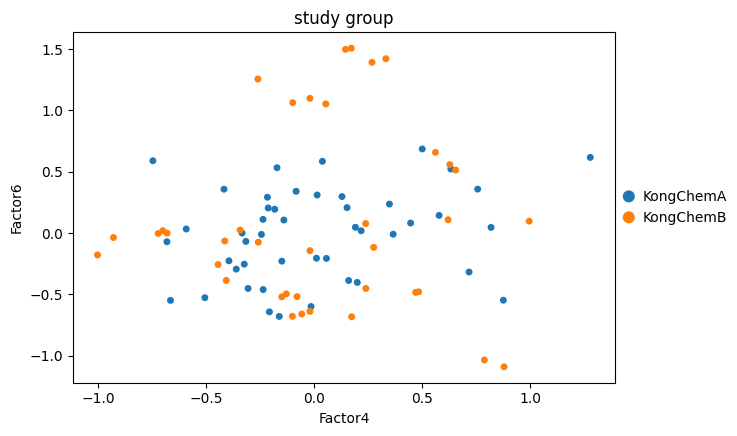

In [77]:
sc.pl.scatter(amodel,
              x = "Factor4",
              y = "Factor6", 
              color  = "study_group", 
              size =100)